In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../Dataset/clean_amazon_store_sales.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df.shape)
df.head()

(5901, 28)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,Shipping Days,Return Status,Profit Margin %,Order Year,Order Month,Order Month No,Order Quarter
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,0,Online,6,Not Returned,38.229375,2019,January,1,Q1
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,0,Online,5,Not Returned,22.000000,2019,January,1,Q1
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.2742,0,Cards,5,Not Returned,29.000000,2019,January,1,Q1
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,0,Online,2,Not Returned,25.000000,2019,January,1,Q1
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,0,Online,5,Not Returned,-17.500000,2019,January,1,Q1


In [2]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,5901.0,NaN,NaN,NaN,5022.422471,1.0,2486.0,5091.0,7456.0,9994.0,2877.977184
Order ID,5901,3003,CA-2020-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,5901,NaN,NaN,NaN,2020-02-29 01:53:57.620742144,2019-01-01 00:00:00,2019-09-11 00:00:00,2020-03-16 00:00:00,2020-09-14 00:00:00,2020-12-31 00:00:00,NaN
Ship Date,5901,NaN,NaN,NaN,2020-03-04 00:08:47.097102336,2019-01-05 00:00:00,2019-09-15 00:00:00,2020-03-19 00:00:00,2020-09-16 00:00:00,2021-01-05 00:00:00,NaN
Ship Mode,5901,4,Standard Class,3451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,5901,773,EP-13915,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,5901,773,Emily Phan,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,5901,3,Consumer,2997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,5901,1,United States,5901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,5901,452,New York City,563,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Orders:", df["Order ID"].nunique())
print("Total Customers:", df["Customer ID"].nunique())
print("Returned Orders:", df.loc[df["Returns"] == 1, "Order ID"].nunique())

Total Sales: 1565804.32
Total Profit: 175262.11
Total Orders: 3003
Total Customers: 773
Returned Orders: 104


In [4]:
plt.rcParams["figure.figsize"] = (11, 6)
sns.set_theme(style="whitegrid")

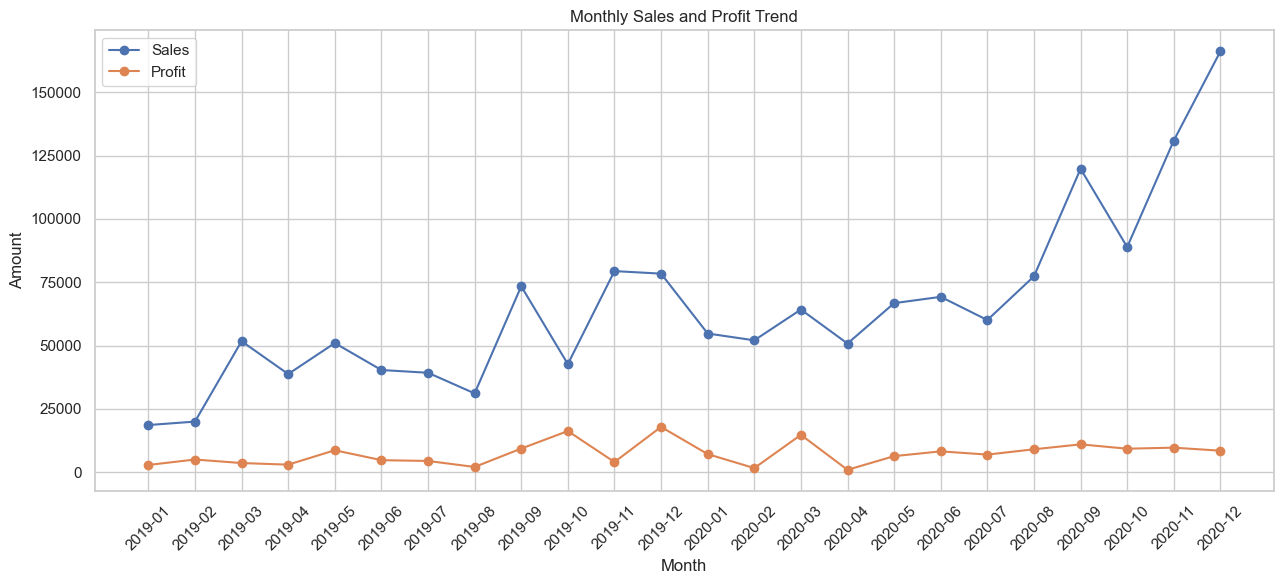

In [5]:
monthly = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .reset_index()
)

monthly["Order Date"] = monthly["Order Date"].astype(str)

plt.figure(figsize=(13, 6))
plt.plot(monthly["Order Date"], monthly["Total_Sales"], marker="o", label="Sales")
plt.plot(monthly["Order Date"], monthly["Total_Profit"], marker="o", label="Profit")

plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

 ### Insight
Monthly sales and profit show changing performance over time. Peak months should be investigated to understand which products, regions, or customer segments drove the increase.

In [6]:
category_performance = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

category_performance

,Total_Sales,Total_Profit
Category,,
Office Supplies,643707.6870,74797.2461
Technology,470587.9910,90458.2486
Furniture,451508.6452,10006.6112


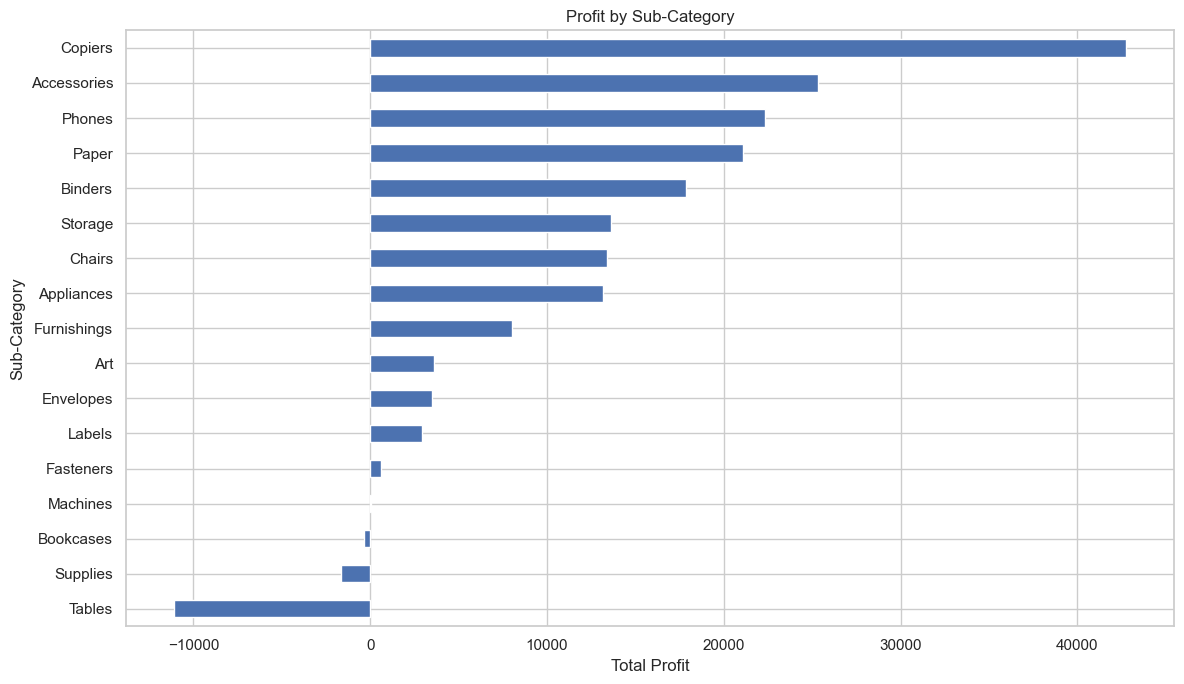

In [7]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(12, 7))
subcategory_profit.plot(kind="barh")

plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

In [8]:
region_performance = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

region_performance

,Total_Sales,Total_Profit
Region,,
West,522441.0520,67859.9582
East,450234.6660,53400.4243
Central,341007.5242,27450.0071
South,252121.0810,26551.7163


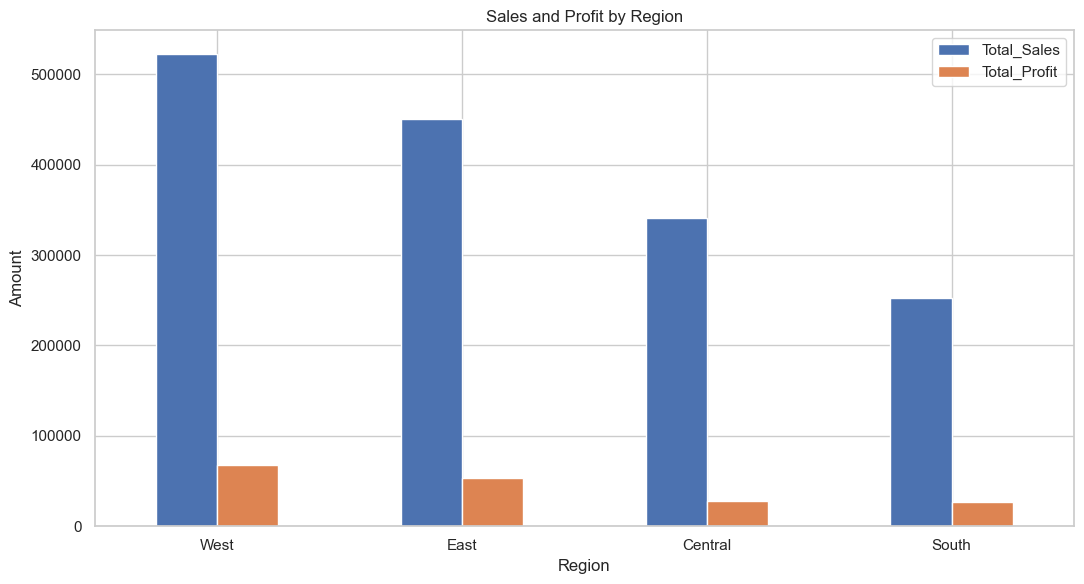

In [9]:
region_performance.plot(kind="bar", figsize=(11, 6))
plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
segment_performance = (
    df.groupby("Segment")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

segment_performance

,Total_Sales,Total_Profit,Total_Orders
Segment,,,
Consumer,753002.1291,81338.5875,1528
Corporate,509743.1262,57805.7991,915
Home Office,303059.0679,36117.7193,560


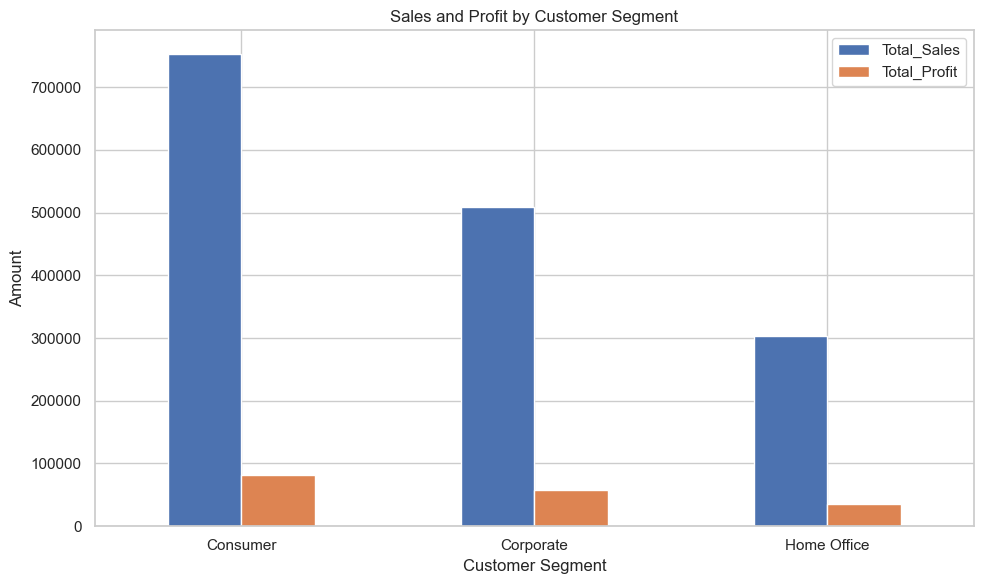

In [11]:
segment_performance[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

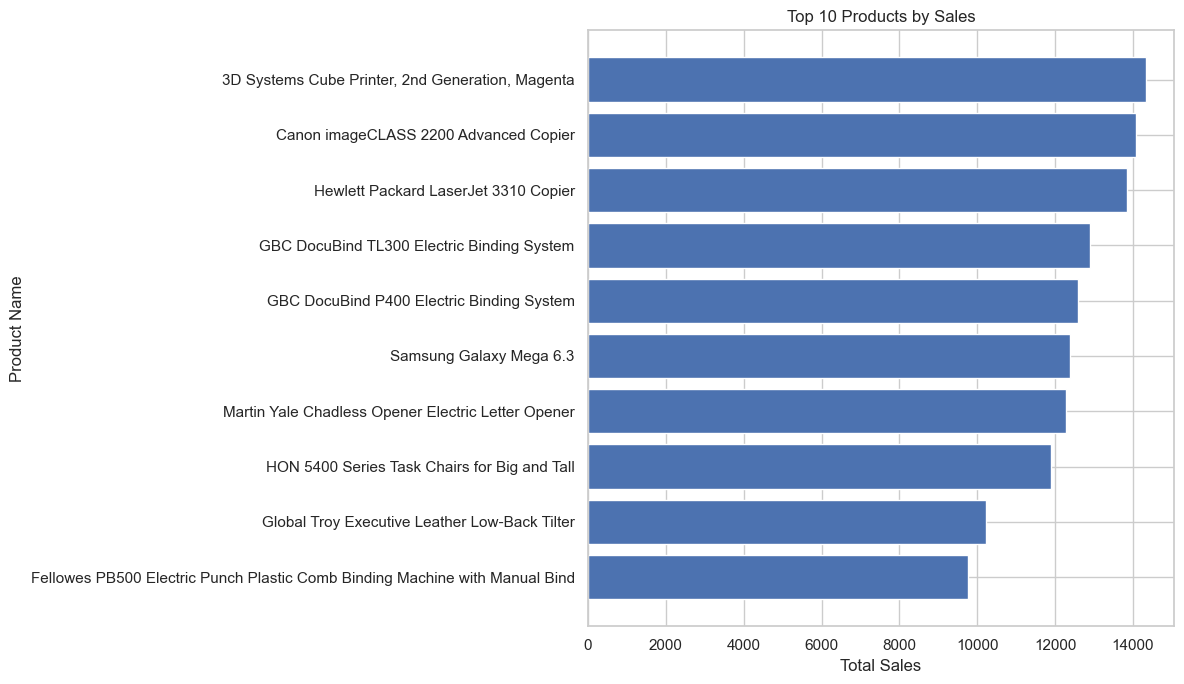

In [12]:
top_products = (
    df.groupby("Product Name")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
      .head(10)
      .sort_values("Total_Sales")
)

plt.figure(figsize=(12, 7))
plt.barh(top_products.index, top_products["Total_Sales"])

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

In [13]:
bottom_products = (
    df.groupby("Product Name")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Profit")
      .head(10)
)

bottom_products

,Total_Sales,Total_Profit
Product Name,,
Cubify CubeX 3D Printer Double Head Print,9323.969,-6239.9792
Cubify CubeX 3D Printer Triple Head Print,3009.980,-3839.9904
Lexmark MX611dhe Monochrome Laser Printer,5676.967,-2719.9840
Bush Advantage Collection Racetrack Conference Table,4334.100,-2019.2396
Ibico EPK-21 Electric Binding System,6437.966,-1285.1932
Martin Yale Chadless Opener Electric Letter Opener,12268.902,-1232.5588
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,1052.500,-986.5625
Bretford “Just In Time” Height-Adjustable Multi-Task Work Tables,3869.900,-964.1940
Zebra GK420t Direct Thermal/Thermal Transfer Printer,703.710,-938.2800


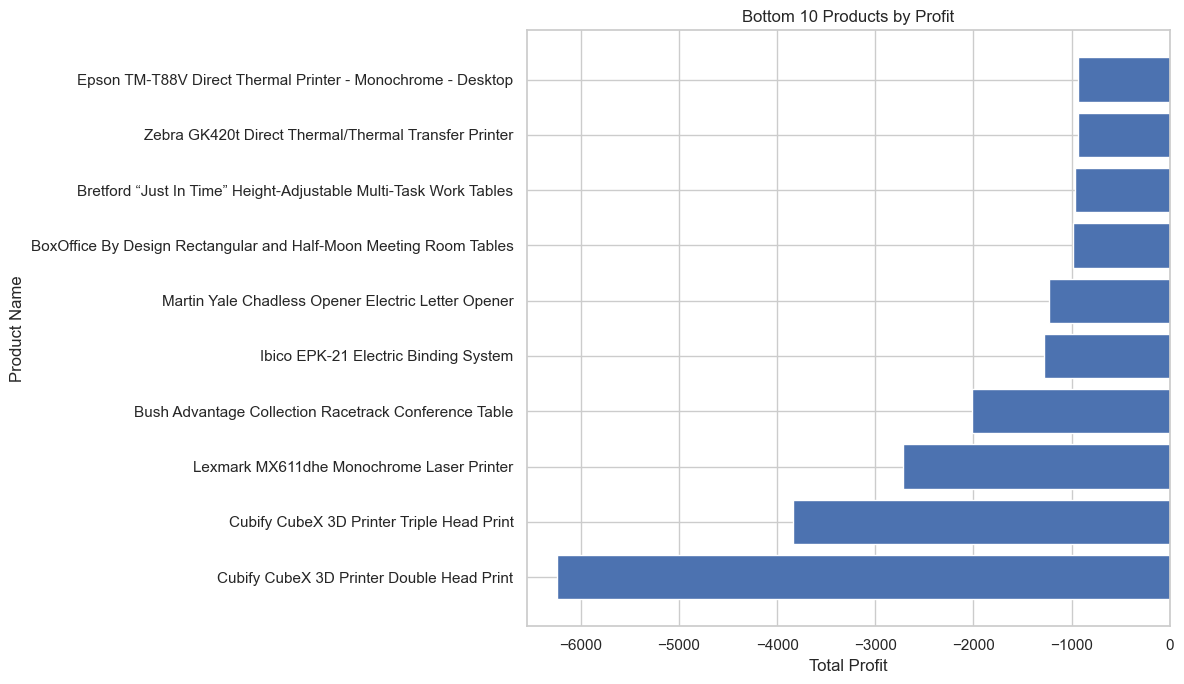

In [14]:
plt.figure(figsize=(12, 7))
plt.barh(bottom_products.index, bottom_products["Total_Profit"])

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

In [15]:
return_category = (
    df.groupby("Category")
      .agg(
          Total_Orders=("Order ID", "nunique"),
          Returned_Orders=("Returns", lambda x: (x == 1).sum())
      )
)

return_category["Return Rate %"] = (
    return_category["Returned_Orders"] /
    return_category["Total_Orders"] * 100
).round(2)

return_category.sort_values("Return Rate %", ascending=False)

,Total_Orders,Returned_Orders,Return Rate %
Category,,,
Office Supplies,2219,165,7.44
Furniture,1040,70,6.73
Technology,915,52,5.68


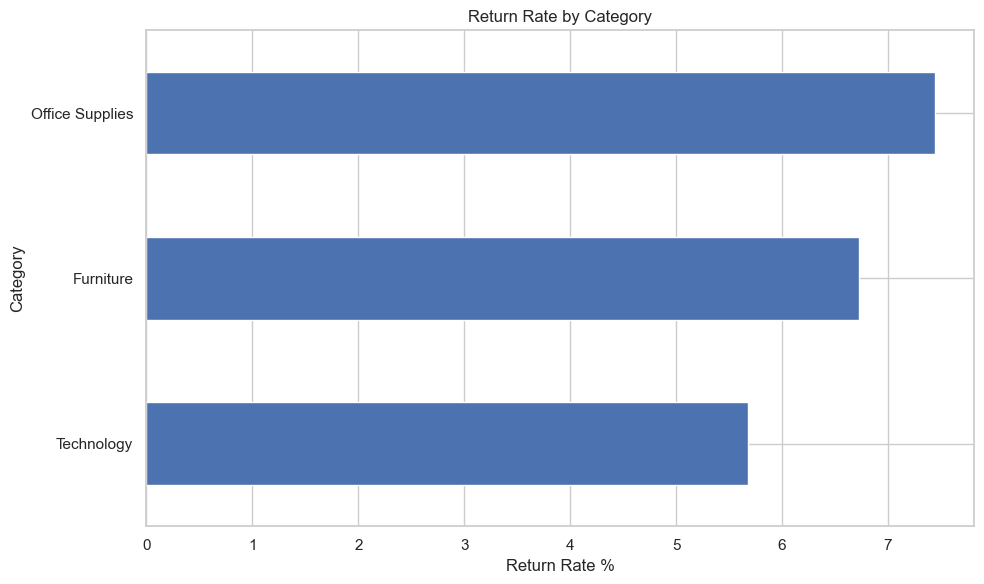

In [16]:
return_category["Return Rate %"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Return Rate by Category")
plt.xlabel("Return Rate %")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [17]:
return_shipping = (
    df.groupby("Ship Mode")
      .agg(
          Total_Orders=("Order ID", "nunique"),
          Returned_Orders=("Returns", lambda x: (x == 1).sum())
      )
)

return_shipping["Return Rate %"] = (
    return_shipping["Returned_Orders"] /
    return_shipping["Total_Orders"] * 100
).round(2)

return_shipping.sort_values("Return Rate %", ascending=False)

,Total_Orders,Returned_Orders,Return Rate %
Ship Mode,,,
First Class,499,66,13.23
Second Class,568,57,10.04
Standard Class,1773,154,8.69
Same Day,163,10,6.13


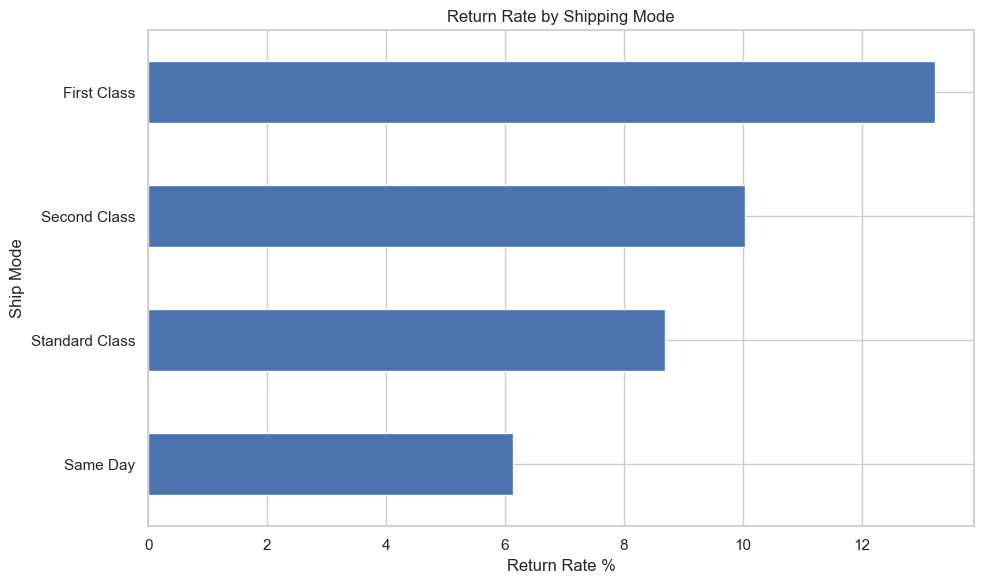

In [18]:
return_shipping["Return Rate %"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Return Rate by Shipping Mode")
plt.xlabel("Return Rate %")
plt.ylabel("Ship Mode")
plt.tight_layout()
plt.show()

In [19]:
payment_sales = (
    df.groupby("Payment Mode")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

payment_sales

Payment Mode
COD       667417.7513
Online    553993.4607
Cards     344393.1112
Name: Sales, dtype: float64

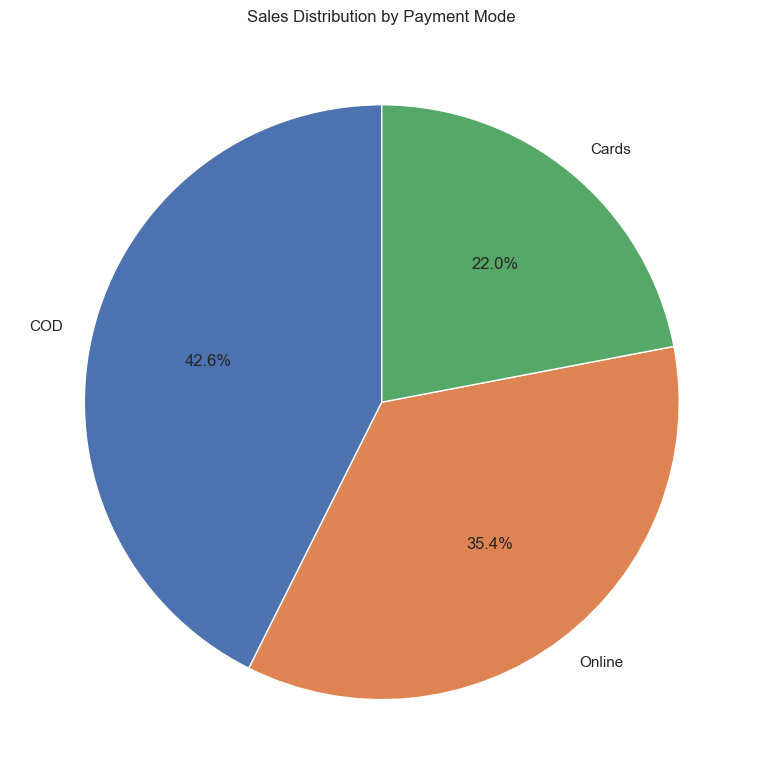

In [20]:
plt.figure(figsize=(8, 8))
plt.pie(
    payment_sales,
    labels=payment_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Payment Mode")
plt.tight_layout()
plt.show()

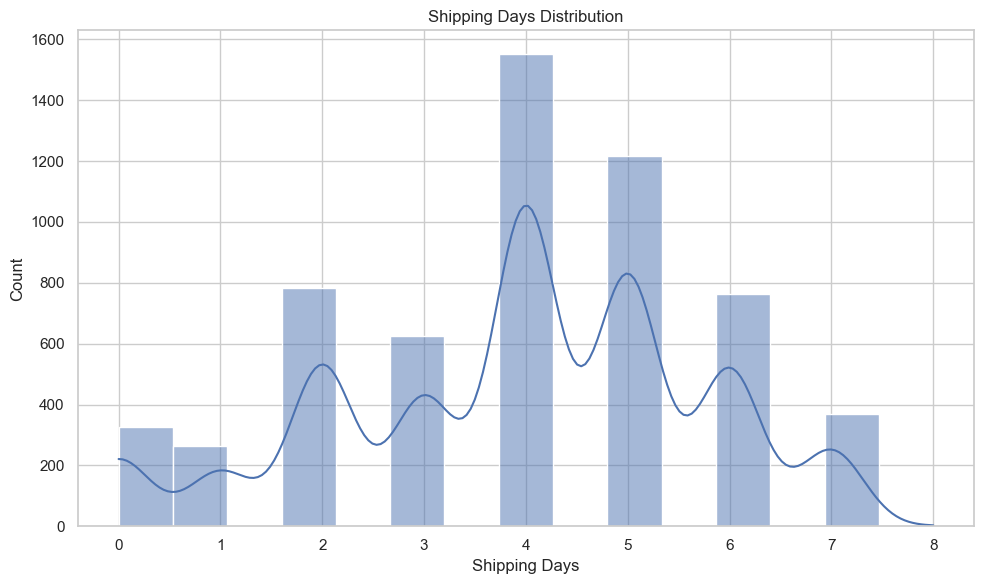

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Shipping Days"].dropna(), bins=15, kde=True)

plt.title("Shipping Days Distribution")
plt.xlabel("Shipping Days")
plt.tight_layout()
plt.show()

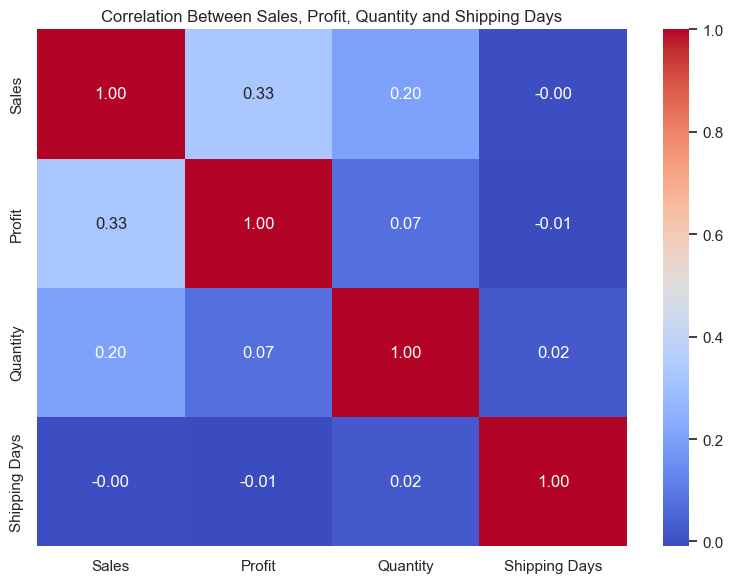

In [22]:
correlation_data = df[["Sales", "Profit", "Quantity", "Shipping Days"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Sales, Profit, Quantity and Shipping Days")
plt.tight_layout()
plt.show()

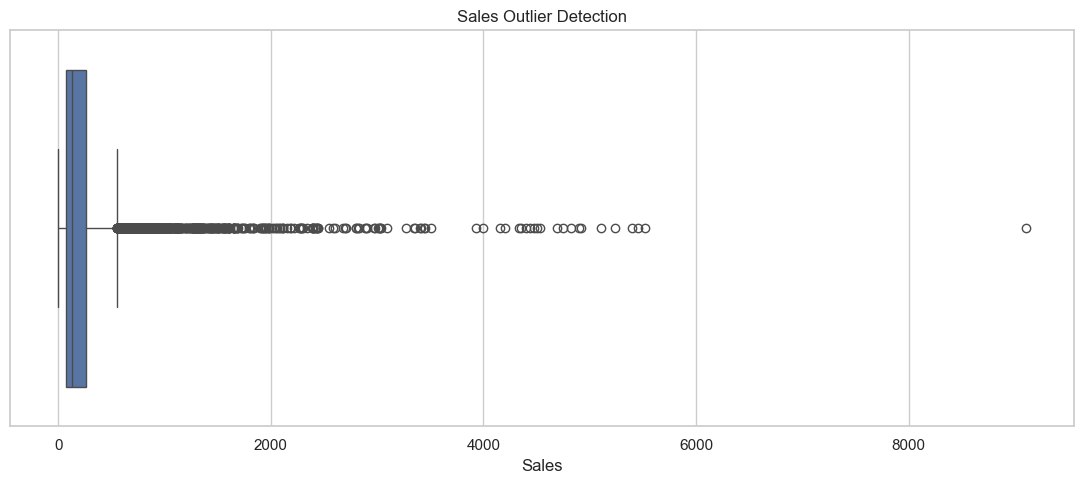

In [23]:
plt.figure(figsize=(11, 5))
sns.boxplot(x=df["Sales"])

plt.title("Sales Outlier Detection")
plt.tight_layout()
plt.show()

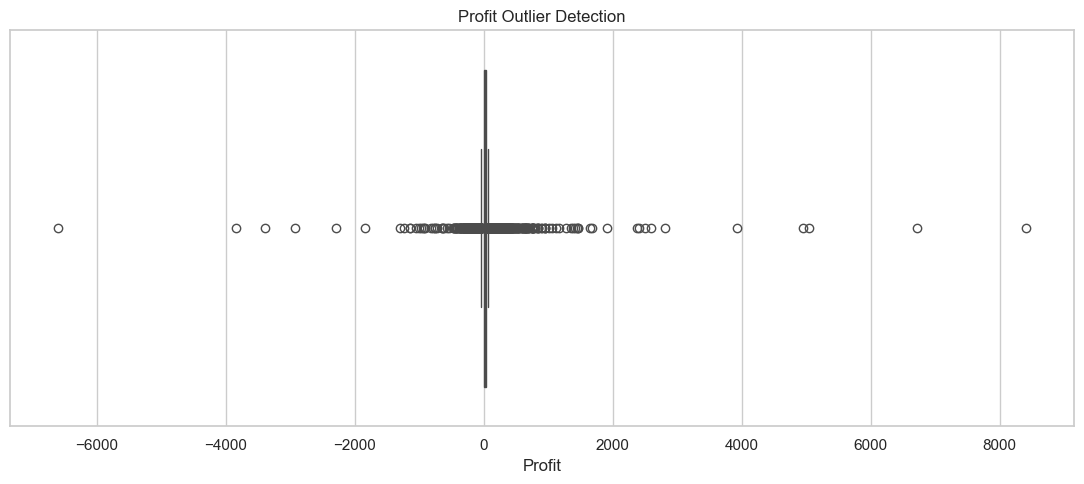

In [24]:
plt.figure(figsize=(11, 5))
sns.boxplot(x=df["Profit"])

plt.title("Profit Outlier Detection")
plt.tight_layout()
plt.show()

In [25]:
insight_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin %",
        "Total Orders",
        "Total Customers",
        "Returned Orders",
        "Average Order Value",
        "Average Shipping Days"
    ],
    "Value": [
        round(df["Sales"].sum(), 2),
        round(df["Profit"].sum(), 2),
        round((df["Profit"].sum() / df["Sales"].sum()) * 100, 2),
        df["Order ID"].nunique(),
        df["Customer ID"].nunique(),
        df.loc[df["Returns"] == 1, "Order ID"].nunique(),
        round(df["Sales"].sum() / df["Order ID"].nunique(), 2),
        round(df["Shipping Days"].mean(), 2)
    ]
})

insight_summary

,Metric,Value
0,Total Sales,1565804.32
1,Total Profit,175262.11
2,Profit Margin %,11.19
3,Total Orders,3003.00
4,Total Customers,773.00
5,Returned Orders,104.00
6,Average Order Value,521.41
7,Average Shipping Days,3.93


# EDA Summary

- Analyzed monthly sales and profit trends to identify peak and low-performing periods.
- Compared category, sub-category, regional, and customer segment performance.
- Identified top-selling products and loss-making products.
- Evaluated return patterns by category and shipping mode.
- Analyzed payment mode preferences and shipping duration.
- Checked relationships between sales, profit, quantity, and shipping days.
- Identified potential outliers in sales and profit without removing valid high-value transactions.